### Lab 1: Knapsack Problem

Copyright **`(c)`** 2025 Giovanni Squillero `<giovanni.squillero@polito.it>`,
    [`https://github.com/squillero/computational-intelligence`](https://github.com/squillero/computational-intelligence),
    Free under certain conditions — see the [`license`](https://github.com/squillero/computational-intelligence/blob/master/LICENSE.md) for details.  

In [1]:
import numpy as np

In [29]:
NUM_KNAPSACKS = 2
NUM_ITEMS = 10
NUM_DIMENSIONS = 2

In [ ]:
VALUES = np.random.randint(0, 100, size=NUM_ITEMS)
WEIGHTS = np.random.randint(0, 100, size=(NUM_ITEMS, NUM_DIMENSIONS))
CONSTRAINTS = np.random.randint(
    0, 100 * NUM_ITEMS // NUM_KNAPSACKS, size=(NUM_KNAPSACKS, NUM_DIMENSIONS)
)

In [46]:
CONSTRAINTS

array([614, 496])

In [32]:
# A random solution
solution = np.array(
    [np.random.random(NUM_ITEMS) < 0.5 for _ in range(NUM_KNAPSACKS)], dtype=np.bool
)

In [33]:
solution

array([[False, False, False,  True,  True, False, False, False, False,
        False],
       [False,  True,  True, False,  True,  True,  True,  True,  True,
        False]])

In [34]:

# Check that the same object does not appear in multiple knapsacks
np.all(solution.sum(axis=0) <= 1)

np.False_

In [35]:

# Check if the solution is valid
all_knapsacks = np.any(solution, axis=0)
np.all(WEIGHTS[all_knapsacks].sum(axis=0) < CONSTRAINTS)
print("Weights:", WEIGHTS[all_knapsacks].sum(axis=0))
print("Constraints:", CONSTRAINTS)

Weights: [405 419]
Constraints: [194  15]


## TEST PROBLEMS

In [47]:

# Problem 1:
rng = np.random.default_rng(seed=42)
NUM_KNAPSACKS = 3
NUM_ITEMS = 20
NUM_DIMENSIONS = 2
VALUES = rng.integers(0, 100, size=NUM_ITEMS)
WEIGHTS = rng.integers(0, 100, size=(NUM_ITEMS, NUM_DIMENSIONS))
CONSTRAINTS = rng.integers(
    0, 100 * NUM_ITEMS // NUM_KNAPSACKS, size=(NUM_KNAPSACKS, NUM_DIMENSIONS)
)

In [73]:
# Problem 2:
rng = np.random.default_rng(seed=42)
NUM_KNAPSACKS = 10
NUM_ITEMS = 100
NUM_DIMENSIONS = 10
VALUES = rng.integers(0, 1000, size=NUM_ITEMS)
WEIGHTS = rng.integers(0, 1000, size=(NUM_ITEMS, NUM_DIMENSIONS))
CONSTRAINTS = rng.integers(
    1000 * 2, 1000 * NUM_ITEMS // NUM_KNAPSACKS, size=(NUM_KNAPSACKS, NUM_DIMENSIONS)
)

In [79]:

# Problem 3:
rng = np.random.default_rng(seed=42)
NUM_KNAPSACKS = 100
NUM_ITEMS = 5000
NUM_DIMENSIONS = 100
VALUES = rng.integers(0, 1000, size=NUM_ITEMS)
WEIGHTS = rng.integers(0, 1000, size=(NUM_ITEMS, NUM_DIMENSIONS))
CONSTRAINTS = rng.integers(
    1000 * 10, 1000 * 2 * NUM_ITEMS // NUM_KNAPSACKS, size=(NUM_KNAPSACKS, NUM_DIMENSIONS))

## Solution

In [80]:
print(VALUES)

print(WEIGHTS)

print(CONSTRAINTS)

[ 89 773 654 ... 819 678 498]
[[197  33 627 ... 319 937 293]
 [550 543 242 ... 942 568 950]
 [436 411 836 ... 664 169 846]
 ...
 [869 582 968 ... 567 291 288]
 [ 97 220 662 ... 171 310 833]
 [656  51 146 ... 286 725 372]]
[[79834 52005 17527 ... 78500 56643 69915]
 [95067 28572 45458 ... 50816 83737 88901]
 [46612 36250 19604 ... 98589 28135 27193]
 ...
 [69672 90152 96973 ... 43906 41364 99258]
 [60364 83491 71527 ... 33636 13114 12777]
 [49805 58803 31629 ... 83824 73369 10897]]


In [81]:
# Generate a random initial solution
initial_solution = np.array(
    [rng.random(NUM_ITEMS) < 0.5 for _ in range(NUM_KNAPSACKS)], dtype=np.bool
)
initial_solution

array([[False,  True,  True, ..., False, False,  True],
       [False, False, False, ..., False,  True, False],
       [ True,  True,  True, ..., False, False,  True],
       ...,
       [ True,  True,  True, ..., False, False, False],
       [False, False, False, ..., False,  True, False],
       [ True, False, False, ..., False, False,  True]], shape=(100, 5000))

In [82]:
def check_solution(solution, debug = 0) -> bool:
    # Check that the same object does not appear in multiple knapsacks
    if not np.all(solution.sum(axis=0) <= 1):
        if debug:
            print("Invalid solution: same object appears in multiple knapsacks")
        return False

    total_weights = np.zeros((NUM_KNAPSACKS, NUM_DIMENSIONS), dtype=np.int32)
    # Check constraints for each knapsack individually
    for k in range(NUM_KNAPSACKS):
        items_in_knapsack = np.where(solution[k])[0]
        total_weights[k] = WEIGHTS[items_in_knapsack].sum(axis=0)

    if not np.all(total_weights < CONSTRAINTS):
        if debug:
            print("Invalid solution: knapsack constraints violated")
            print("Weights:", total_weights)
            print("Constraints:", CONSTRAINTS)
        return False

    return True

In [ ]:
def tweak_solution(solution):
    new_solution = solution.copy()
    # Randomly choose to add or remove an item
    if np.random.rand() < 0.5:
        # Add an item to a random knapsack
        knapsack = np.random.randint(NUM_KNAPSACKS)
        item = np.random.randint(NUM_ITEMS)
        # Ensure the item is not already in another knapsack
        if not np.any(new_solution[:, item]):
            new_solution[knapsack, item] = True
    else:
        # Remove an item from a random knapsack
        knapsack = np.random.randint(NUM_KNAPSACKS)
        items_in_knapsack = np.where(new_solution[knapsack])[0]
        if len(items_in_knapsack) > 0:
            item = np.random.choice(items_in_knapsack)
            new_solution[knapsack, item] = False
    return new_solution

In [84]:
# Check that the same object does not appear in multiple knapsacks
if not np.all(initial_solution.sum(axis=0) <= 1):
    indices = np.where(initial_solution.sum(axis=0) > 1)[0]
    for i in indices:
        knapsacks = np.where(initial_solution[:, i])[0]
        to_remove = rng.choice(knapsacks, size=len(knapsacks) - 1, replace=False)
        initial_solution[to_remove, i] = False
np.all(initial_solution.sum(axis=0) <= 1)

total_weights = np.zeros((NUM_KNAPSACKS, NUM_DIMENSIONS), dtype=np.int32)
# Check constraints for each knapsack individually
for k in range(NUM_KNAPSACKS):
    items_in_knapsack = initial_solution[k]
    total_weights[k] = WEIGHTS[items_in_knapsack].sum(axis=0)


if not np.all(total_weights < CONSTRAINTS):
    print(f"solution  is not valid")
    print("Weights:", total_weights)
    print("Constraints:", CONSTRAINTS)
else:
    print(f"Knapsack is valid")

# we want to create a valid initial solution so we will remove items until the solution is valid
while not np.all(total_weights < CONSTRAINTS):
    # Find a knapsack that is not valid
    invalid_knapsacks = np.where(np.any(total_weights >= CONSTRAINTS, axis=1))[0]
    k = rng.choice(invalid_knapsacks)
    # Find items in the knapsack
    items_in_knapsack = np.where(initial_solution[k])[0]
    if len(items_in_knapsack) == 0:
        continue
    # Remove a random item from the knapsack
    item_to_remove = rng.choice(items_in_knapsack)
    initial_solution[k, item_to_remove] = False
    # Update total weights
    total_weights[k] = WEIGHTS[initial_solution[k]].sum(axis=0)


total_weights = np.zeros((NUM_KNAPSACKS, NUM_DIMENSIONS), dtype=np.int32)
# Check constraints for each knapsack individually
for k in range(NUM_KNAPSACKS):
    items_in_knapsack = initial_solution[k]
    total_weights[k] = WEIGHTS[items_in_knapsack].sum(axis=0)


if not np.all(total_weights < CONSTRAINTS):
    print(f"solution  is not valid")
    print("Weights:", total_weights)
    print("Constraints:", CONSTRAINTS)
else:
    print(f"Knapsack is valid")
    print("Weights:", total_weights)
    print("Constraints:", CONSTRAINTS)


solution  is not valid
Weights: [[28104 26758 25678 ... 26780 25304 26614]
 [21099 27997 25259 ... 23659 29972 27893]
 [24647 24765 24041 ... 25239 23700 26513]
 ...
 [24352 26539 25748 ... 28251 24412 25555]
 [21913 22287 22643 ... 20920 22227 18833]
 [23378 20415 26359 ... 22158 20504 22778]]
Constraints: [[79834 52005 17527 ... 78500 56643 69915]
 [95067 28572 45458 ... 50816 83737 88901]
 [46612 36250 19604 ... 98589 28135 27193]
 ...
 [69672 90152 96973 ... 43906 41364 99258]
 [60364 83491 71527 ... 33636 13114 12777]
 [49805 58803 31629 ... 83824 73369 10897]]
Knapsack is valid
Weights: [[10792 12813 10223 ... 11770 10610 12893]
 [ 7969  9612  8007 ...  8309  9697  7518]
 [ 7185  8581  9490 ... 11149  8849  8670]
 ...
 [10110 11115 11177 ... 11108  8963  9734]
 [10455 10697 10496 ...  8722 11207  8359]
 [ 8720  6948  9664 ... 10006  7888  8861]]
Constraints: [[79834 52005 17527 ... 78500 56643 69915]
 [95067 28572 45458 ... 50816 83737 88901]
 [46612 36250 19604 ... 98589 28135 2

In [ ]:
print(check_solution(initial_solution, debug=1))

initial_solution_values = np.sum(np.sum(initial_solution * VALUES, axis=1))

print("Initial solution values:", initial_solution_values)

# We can now use initial_solution as a valid starting point for our optimization algorithm
# We will only climb and accept only solution that are valid and better than the current solution
MAX_ITERATIONS = 100000
current_solution = initial_solution
current_solution_values = initial_solution_values

max_values = np.sum(VALUES)
print("Max values:", max_values)

for _ in range(MAX_ITERATIONS or current_solution_values == max_values):
    new_solution = tweak_solution(current_solution)
    if check_solution(new_solution):
        new_solution_values = np.sum(np.sum(new_solution * VALUES, axis=1))
        if new_solution_values > current_solution_values:
            current_solution = new_solution
            current_solution_values = new_solution_values
            #print("New best solution values:", current_solution_values)

print("Final solution values:", current_solution_values)

True
Initial solution values: 1006024
Max values: 2490698
New best solution values: 1006320
New best solution values: 1006485
New best solution values: 1007474
New best solution values: 1008057
New best solution values: 1008787
New best solution values: 1009294
New best solution values: 1009518
New best solution values: 1010038
New best solution values: 1010244
New best solution values: 1011168
New best solution values: 1012042
New best solution values: 1012884
New best solution values: 1013345
New best solution values: 1013617
New best solution values: 1013770
New best solution values: 1014739
New best solution values: 1015475
New best solution values: 1016207
New best solution values: 1016457
New best solution values: 1016997
New best solution values: 1017634
New best solution values: 1017975
New best solution values: 1018942
New best solution values: 1019821
New best solution values: 1020066
New best solution values: 1020578
New best solution values: 1021175
New best solution values

## OK now we have a valid method we will try to improve it

we will map the knapstack in a different way, with just one list of size NUM_ITEMS
each position will contain the knapstack number where the item is placed, or -1 if not placed

we will introduce a new parameter, the "emptiness ratio", that is the percentage of knapstack left empty, this helps us decide if we want to add a new item or remove an existing one or move an item from one knapstack to another


In [141]:
# Problem 1:
rng = np.random.default_rng(seed=42)
NUM_KNAPSACKS = 3
NUM_ITEMS = 20
NUM_DIMENSIONS = 2
VALUES = rng.integers(0, 100, size=NUM_ITEMS)
WEIGHTS = rng.integers(0, 100, size=(NUM_ITEMS, NUM_DIMENSIONS))
CONSTRAINTS = rng.integers(
    0, 100 * NUM_ITEMS // NUM_KNAPSACKS, size=(NUM_KNAPSACKS, NUM_DIMENSIONS)
)

In [154]:
# Problem 2:
rng = np.random.default_rng(seed=42)
NUM_KNAPSACKS = 10
NUM_ITEMS = 100
NUM_DIMENSIONS = 10
VALUES = rng.integers(0, 1000, size=NUM_ITEMS)
WEIGHTS = rng.integers(0, 1000, size=(NUM_ITEMS, NUM_DIMENSIONS))
CONSTRAINTS = rng.integers(
    1000 * 2, 1000 * NUM_ITEMS // NUM_KNAPSACKS, size=(NUM_KNAPSACKS, NUM_DIMENSIONS)
)

In [146]:
# Problem 3:
rng = np.random.default_rng(seed=42)
NUM_KNAPSACKS = 100
NUM_ITEMS = 5000
NUM_DIMENSIONS = 100
VALUES = rng.integers(0, 1000, size=NUM_ITEMS)
WEIGHTS = rng.integers(0, 1000, size=(NUM_ITEMS, NUM_DIMENSIONS))
CONSTRAINTS = rng.integers(
    1000 * 10, 1000 * 2 * NUM_ITEMS // NUM_KNAPSACKS, size=(NUM_KNAPSACKS, NUM_DIMENSIONS))

In [ ]:
def fitness(solution):
    total_value = 0
    total_weights = np.zeros((NUM_KNAPSACKS, NUM_DIMENSIONS), dtype=np.int32)

    for item, knapsack in enumerate(solution):
        if knapsack != -1:
            total_value += VALUES[item]
            total_weights[knapsack] += WEIGHTS[item]

    # Check constraints
    if np.any(total_weights > CONSTRAINTS):
        return -1, 0, 0  # Invalid solution, return remaining capacities (may be negative)

    return total_value, CONSTRAINTS - total_weights, np.min((CONSTRAINTS - total_weights) / CONSTRAINTS, axis=1)



(0, array([[79834, 52005, 17527, ..., 78500, 56643, 69915],
       [95067, 28572, 45458, ..., 50816, 83737, 88901],
       [46612, 36250, 19604, ..., 98589, 28135, 27193],
       ...,
       [69672, 90152, 96973, ..., 43906, 41364, 99258],
       [60364, 83491, 71527, ..., 33636, 13114, 12777],
       [49805, 58803, 31629, ..., 83824, 73369, 10897]], shape=(100, 100)), array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]))


In [148]:
def tweak_solution(solution, value):
    new_solution = solution.copy()
    
    mean_remaining_ratio = np.mean(value[2])
    if mean_remaining_ratio > 0.15:
        prob_add = 0.99
    else:
        prob_add = 0.65

    if np.random.rand() < prob_add:
        # Add an item to a random knapsack
        empty_items = np.where(new_solution == -1)[0]
        if len(empty_items) > 0:
            item = np.random.choice(empty_items)
            knapsack = np.random.randint(NUM_KNAPSACKS)
            new_solution[item] = knapsack

    else:
        # switch an item from one knapsack to another or remove it
        filled_items = np.where(new_solution != -1)[0]
        if len(filled_items) > 0:
            item = np.random.choice(filled_items)
            if np.random.rand() < 0.05:
                # remove it
                new_solution[item] = -1
            else:
                # switch it
                knapsack = new_solution[item]
                new_knapsack = (knapsack + np.random.randint(1, NUM_KNAPSACKS)) % NUM_KNAPSACKS
                new_solution[item] = new_knapsack
    new_value = fitness(new_solution)

    if new_value[0] != -1:
        return new_solution, new_value
    
    return solution, value

In [ ]:
MAX_ITERATIONS = 50000

from IPython.display import display
import ipywidgets as widgets

initial_solution =np.full(NUM_ITEMS, -1, dtype=np.int32)  # -1 means not in any knapsack
value = fitness(initial_solution)

# we will save the best solution found and the value to print a graph at the end
best_solution = initial_solution
best_value = value

value_history = [value]

bar = widgets.IntProgress(min=0, max=MAX_ITERATIONS)
display(bar)
for i in range(MAX_ITERATIONS):
    initial_solution, value = tweak_solution(initial_solution, value)
    value_history.append(value)
    if value[0] > best_value[0]:
        best_solution = initial_solution
        best_value = value
    bar.value = i+1
    bar.description = f"{((i+1)/MAX_ITERATIONS)*100:.2f}%"




print(value[0])
print(best_value[0])

IntProgress(value=0, max=50000)

Progress: 0.00%
Progress: 0.00%
Progress: 0.01%
Progress: 0.01%
Progress: 0.01%
Progress: 0.01%
Progress: 0.01%
Progress: 0.02%
Progress: 0.02%
Progress: 0.02%
Progress: 0.02%
Progress: 0.02%
Progress: 0.03%
Progress: 0.03%
Progress: 0.03%
Progress: 0.03%
Progress: 0.03%
Progress: 0.04%
Progress: 0.04%
Progress: 0.04%
Progress: 0.04%
Progress: 0.04%
Progress: 0.05%
Progress: 0.05%
Progress: 0.05%
Progress: 0.05%
Progress: 0.05%
Progress: 0.06%
Progress: 0.06%
Progress: 0.06%
Progress: 0.06%
Progress: 0.06%
Progress: 0.07%
Progress: 0.07%
Progress: 0.07%
Progress: 0.07%
Progress: 0.07%
Progress: 0.08%
Progress: 0.08%
Progress: 0.08%
Progress: 0.08%
Progress: 0.08%
Progress: 0.09%
Progress: 0.09%
Progress: 0.09%
Progress: 0.09%
Progress: 0.09%
Progress: 0.10%
Progress: 0.10%
Progress: 0.10%
Progress: 0.10%
Progress: 0.10%
Progress: 0.11%
Progress: 0.11%
Progress: 0.11%
Progress: 0.11%
Progress: 0.11%
Progress: 0.12%
Progress: 0.12%
Progress: 0.12%
Progress: 0.12%
Progress: 0.12%
Progress

Theorical max: 2490698


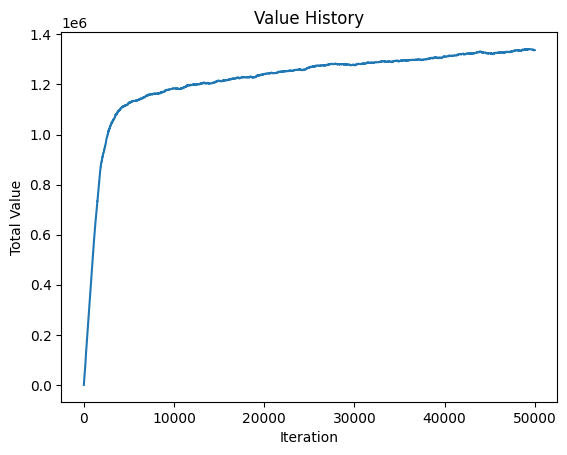

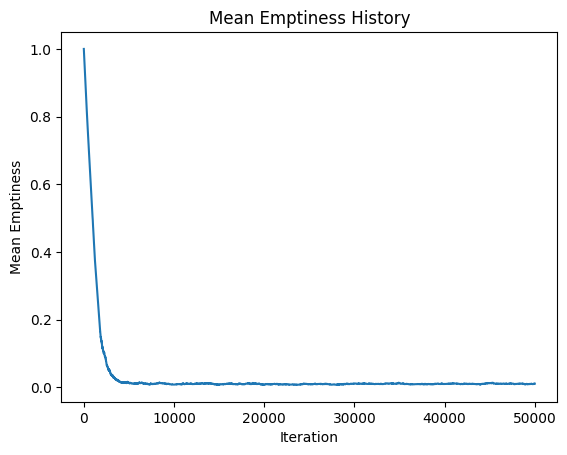

Best mean emptiness: 0.009434588443390951
Final mean emptiness: 0.011182421944682126


In [153]:
import matplotlib.pyplot as plt

theorical_max = np.sum(VALUES)
print("Theorical max:", theorical_max)


values = [v[0] for v in value_history]
plt.plot(range(len(value_history)), values)
plt.xlabel('Iteration')
plt.ylabel('Total Value')
plt.title('Value History')
plt.show()

mean_emptiness = [np.mean(v[2]) for v in value_history]
plt.figure()
plt.plot(range(len(value_history)), mean_emptiness)
plt.xlabel('Iteration')
plt.ylabel('Mean Emptiness')
plt.title('Mean Emptiness History')
plt.show()

best_mean_emptiness = np.mean(best_value[2])
print("Best mean emptiness:", best_mean_emptiness)
final_mean_emptiness = np.mean(value[2])
print("Final mean emptiness:", final_mean_emptiness)

## Conclusion
The new mapping is more compact and easier to manage. The mutation and crossover operations are simplified, leading to potentially better performance in finding optimal solutions. Further testing and tuning of the genetic algorithm parameters may yield even better results.

